# Lab 15: Finding Correlation
## IBM Data Analytics Capstone Project
### Objective: Analyze compensation distribution, remove outliers, and identify correlations between key variables

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


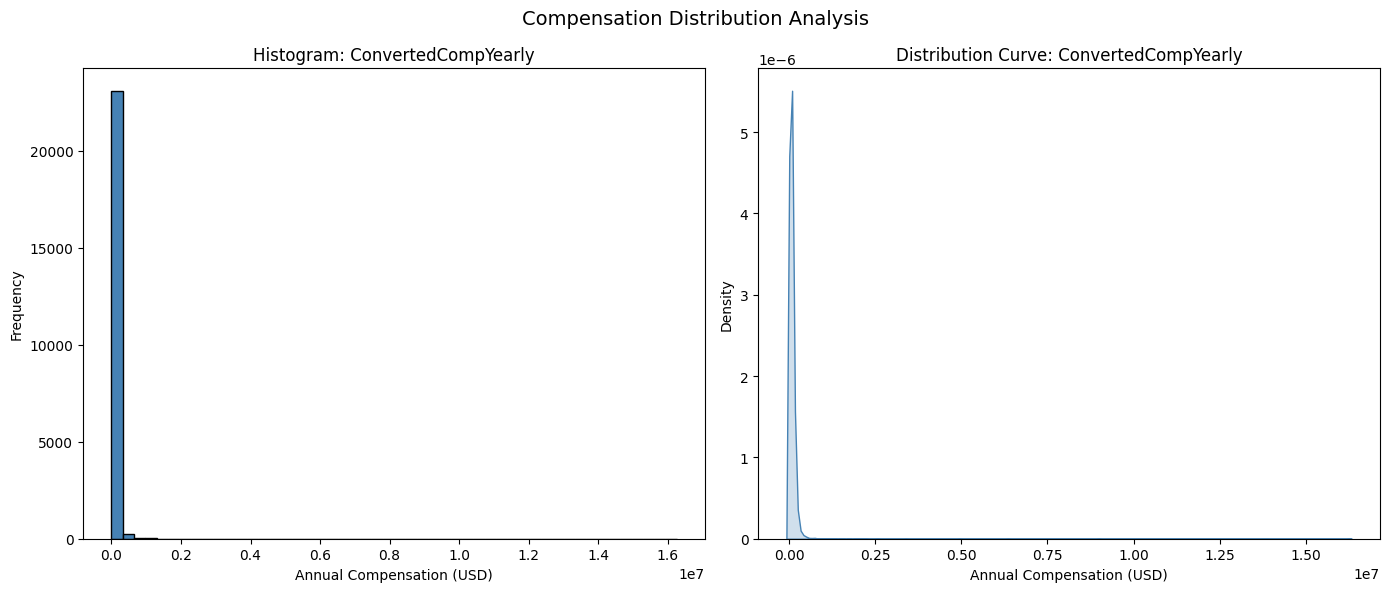

Mean: $86,155.29
Median: $65,000.00
Std Dev: $186,756.97
Distribution plots saved!


In [2]:
# Distribution and histogram for ConvertedCompYearly
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
comp_data = df['ConvertedCompYearly'].dropna()
axes[0].hist(comp_data, bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Histogram: ConvertedCompYearly')
axes[0].set_xlabel('Annual Compensation (USD)')
axes[0].set_ylabel('Frequency')

# Distribution curve (KDE)
sns.kdeplot(data=comp_data, ax=axes[1], color='steelblue', fill=True)
axes[1].set_title('Distribution Curve: ConvertedCompYearly')
axes[1].set_xlabel('Annual Compensation (USD)')
axes[1].set_ylabel('Density')

plt.suptitle('Compensation Distribution Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('comp_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean: ${comp_data.mean():,.2f}")
print(f"Median: ${comp_data.median():,.2f}")
print(f"Std Dev: ${comp_data.std():,.2f}")
print("Distribution plots saved!")

In [3]:
# Filter for full-time employees
fulltime_df = df[df['Employment'] == 'Employed, full-time']
median_fulltime = fulltime_df['ConvertedCompYearly'].median()

print(f"Total full-time employees: {len(fulltime_df):,}")
print(f"Median compensation (full-time): ${median_fulltime:,.2f}")
print(f"Mean compensation (full-time): ${fulltime_df['ConvertedCompYearly'].mean():,.2f}")
print(f"\nComparison:")
print(f"  All respondents median: ${df['ConvertedCompYearly'].median():,.2f}")
print(f"  Full-time employees median: ${median_fulltime:,.2f}")

Total full-time employees: 39,041
Median compensation (full-time): $69,814.00
Mean compensation (full-time): $88,921.11

Comparison:
  All respondents median: $65,000.00
  Full-time employees median: $69,814.00


/var/folders/l6/_t_zyy_55010xg3998z5sfyc0000gn/T/ipykernel_86208/3298487866.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_countries, x='Country', y='ConvertedCompYearly', palette='viridis')


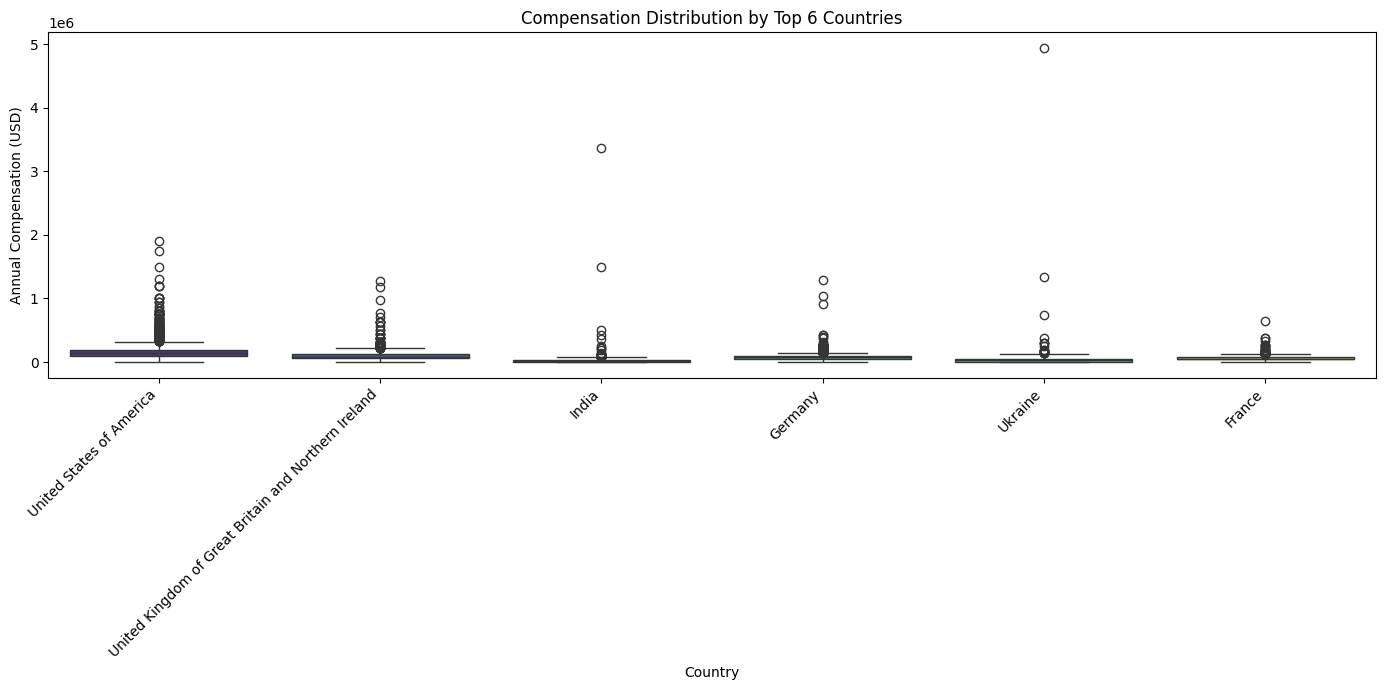

Country compensation box plots saved!


In [4]:
# Top 6 countries by respondents
top_countries = df['Country'].value_counts().head(6).index
df_countries = df[df['Country'].isin(top_countries)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_countries, x='Country', y='ConvertedCompYearly', palette='viridis')
plt.title('Compensation Distribution by Top 6 Countries')
plt.xlabel('Country')
plt.ylabel('Annual Compensation (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('comp_by_country.png', dpi=150, bbox_inches='tight')
plt.show()
print("Country compensation box plots saved!")

In [5]:
# Calculate IQR and remove outliers
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"IQR: ${IQR:,.2f}")
print(f"Lower Bound: ${lower_bound:,.2f}")
print(f"Upper Bound: ${upper_bound:,.2f}")

# Create clean DataFrame
df_clean = df[(df['ConvertedCompYearly'] >= lower_bound) & 
              (df['ConvertedCompYearly'] <= upper_bound)]

print(f"\nOriginal shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]:,}")
print("Outliers removed!")

IQR: $75,259.50
Lower Bound: $-80,177.25
Upper Bound: $220,860.75

Original shape: (65437, 114)
Clean shape: (22457, 114)
Rows removed: 42,980
Outliers removed!


Correlation Matrix:
                     ConvertedCompYearly  WorkExp  JobSatPoints_1
ConvertedCompYearly                1.000    0.407          -0.060
WorkExp                            0.407    1.000          -0.032
JobSatPoints_1                    -0.060   -0.032           1.000


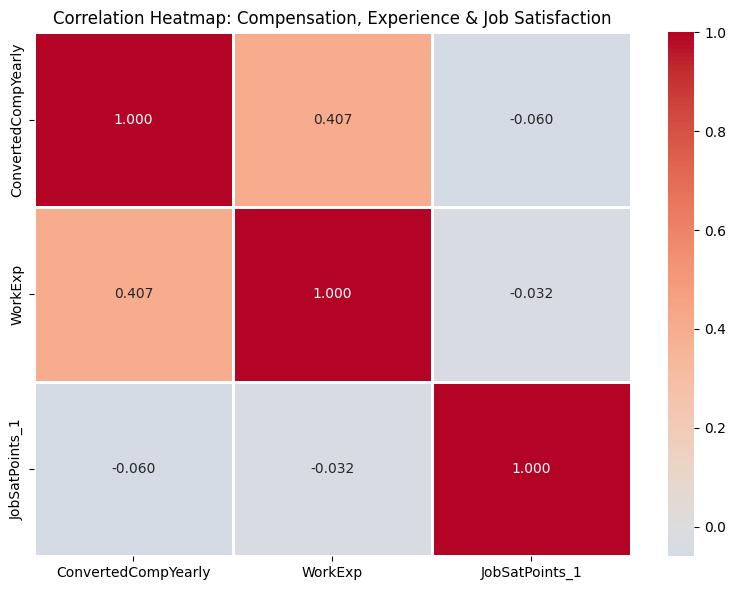

Correlation heatmap saved!


In [6]:
# Correlations between key variables
corr_cols = ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
corr_matrix = df_clean[corr_cols].dropna().corr()

print("Correlation Matrix:")
print(corr_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', 
            cmap='coolwarm', center=0, linewidths=1)
plt.title('Correlation Heatmap: Compensation, Experience & Job Satisfaction')
plt.tight_layout()
plt.savefig('correlation_heatmap_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved!")

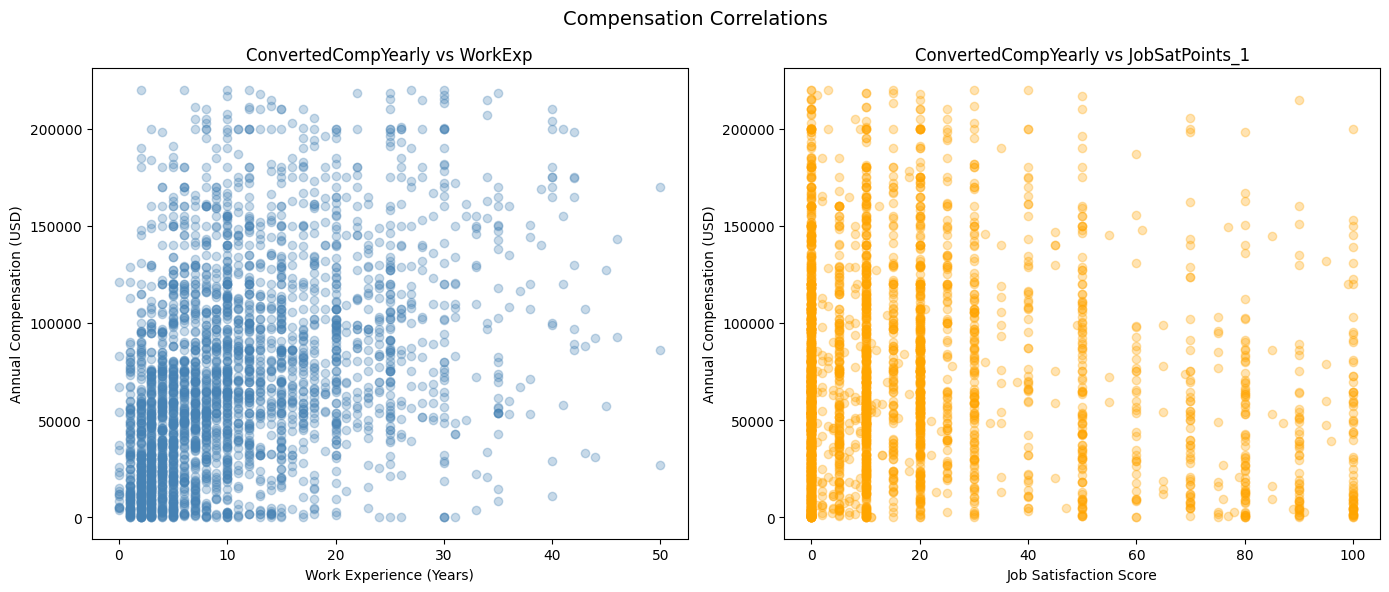

Scatter plots saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter 1: CompYearly vs WorkExp
sample = df_clean[['ConvertedCompYearly', 'WorkExp', 
                   'JobSatPoints_1']].dropna().sample(3000, random_state=42)

axes[0].scatter(sample['WorkExp'], sample['ConvertedCompYearly'], 
                alpha=0.3, color='steelblue')
axes[0].set_title('ConvertedCompYearly vs WorkExp')
axes[0].set_xlabel('Work Experience (Years)')
axes[0].set_ylabel('Annual Compensation (USD)')

# Scatter 2: CompYearly vs JobSatPoints_1
axes[1].scatter(sample['JobSatPoints_1'], sample['ConvertedCompYearly'],
                alpha=0.3, color='orange')
axes[1].set_title('ConvertedCompYearly vs JobSatPoints_1')
axes[1].set_xlabel('Job Satisfaction Score')
axes[1].set_ylabel('Annual Compensation (USD)')

plt.suptitle('Compensation Correlations', fontsize=14)
plt.tight_layout()
plt.savefig('scatter_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plots saved!")

## Summary 

### Key Correlations:
- CompYearly & WorkExp: **0.407** (moderate positive)
- CompYearly & JobSatPoints_1: **-0.060** (near zero)
- WorkExp & JobSatPoints_1: **-0.032** (near zero)

### Key Insight:
More work experience moderately increases compensation
but neither experience nor compensation significantly
affects job satisfaction scores.